In [15]:
import dotenv
import os
import pandas as pd
import irw
import polars as pl
import pairadigm as pdm
dotenv.load_dotenv()

True

## Data processing

In [3]:
df = irw.fetch("facit_yount_2021_hadsx")
df = pl.DataFrame(df)
print(df.shape)
df.head()

(8512, 4)


id,date,item,resp
i64,i64,str,i64
2484565,1172250820,"""hadsx4""",1
2484565,1172250820,"""hadsx7""",1
2484565,1172250820,"""hadsx14""",1
2484576,1172250903,"""hadsx13""",1
2484576,1172250903,"""hadsx10""",1


In [4]:
df.select(pl.col("resp").value_counts())

resp
struct[2]
"{1,2339}"
"{3,2158}"
"{2,1971}"
"{4,2044}"


In [5]:
df.select(pl.col("item").value_counts())

item
struct[2]
"{""hadsx5"",608}"
"{""hadsx10"",608}"
"{""hadsx3"",608}"
"{""hadsx4"",608}"
"{""hadsx6"",608}"
…
"{""hadsx12"",608}"
"{""hadsx9"",608}"
"{""hadsx11"",608}"


In [6]:
text = irw.itemtext("facit_yount_2021_hadsx")
text = pl.DataFrame(text)
print(text.shape)
text.head()

(56, 9)


table,section_id,item,instrument,instructions,section_prompt,item_text,option_text,resp
str,str,str,str,str,str,str,str,i64
"""facit_yount_2021_hadsx""","""main""","""hadsx14""","""Depression scale""","""NA""","""During the past 7 days""","""I can enjoy a good book or rad…","""Sometimes""",2
"""facit_yount_2021_hadsx""","""main""","""hadsx14""","""Depression scale""","""NA""","""During the past 7 days""","""I can enjoy a good book or rad…","""Very seldom""",4
"""facit_yount_2021_hadsx""","""main""","""hadsx14""","""Depression scale""","""NA""","""During the past 7 days""","""I can enjoy a good book or rad…","""Not often""",3
"""facit_yount_2021_hadsx""","""main""","""hadsx14""","""Depression scale""","""NA""","""During the past 7 days""","""I can enjoy a good book or rad…","""Often""",1
"""facit_yount_2021_hadsx""","""main""","""hadsx7""","""Depression scale""","""NA""","""During the past 7 days""","""I can laugh and see the funny …","""Not at all""",4


In [7]:
# text = text.with_columns(
#     (pl.col("section_prompt") + ": " + 
#      pl.col("item_text") + " " +
#      pl.col("option_text"))
#      .alias("combined_text")
# )

# text.write_csv("../data/processed/facit_yount_2021_hadsx_itemtext.csv")
# text.head()

In [8]:
text = text.group_by("item").agg(
    pl.col("section_prompt").first(),
    pl.col("item_text").first(),
    pl.col("option_text").str.join("\n").alias("options")
).with_columns(
    (pl.col("section_prompt") + ": " + 
     pl.col("item_text") + "\n" +
     pl.col("options"))
    .alias("combined_text")
).drop("options")

text.write_csv("../data/processed/facit_yount_2021_hadsx_itemtext (full_item).csv")
text.head()

item,section_prompt,item_text,combined_text
str,str,str,str
"""hadsx5""","""During the past 7 days""","""I get a sort of frightened fee…","""During the past 7 days: I get …"
"""hadsx14""","""During the past 7 days""","""I can enjoy a good book or rad…","""During the past 7 days: I can …"
"""hadsx12""","""During the past 7 days""","""I get sudden feelings of panic…","""During the past 7 days: I get …"
"""hadsx2""","""During the past 7 days""","""I feel as if I am slowed down:""","""During the past 7 days: I feel…"
"""hadsx3""","""During the past 7 days""","""I still enjoy the things I use…","""During the past 7 days: I stil…"


In [9]:
# from charset_normalizer import from_path
# res = from_path("../data/processed/facit_yount_2021_hadsx_itemtext_annotated.csv")
# best = res.best()
# # print(best)                 # human-readable summary
# print("encoding:", best.encoding)

In [10]:
# # Loading the annotated text
# text = pl.read_csv("../data/processed/facit_yount_2021_hadsx_itemtext_annotated.csv", 
#                    encoding="mac_iceland")
# text.head()

In [11]:
df_merged = df.join(text, on=["item"], how="left")
print(df_merged.shape)
df_merged.head()

(8512, 7)


id,date,item,resp,section_prompt,item_text,combined_text
i64,i64,str,i64,str,str,str
2484565,1172250820,"""hadsx4""",1,"""During the past 7 days""","""I get a sort of frightened fee…","""During the past 7 days: I get …"
2484565,1172250820,"""hadsx7""",1,"""During the past 7 days""","""I can laugh and see the funny …","""During the past 7 days: I can …"
2484565,1172250820,"""hadsx14""",1,"""During the past 7 days""","""I can enjoy a good book or rad…","""During the past 7 days: I can …"
2484576,1172250903,"""hadsx13""",1,"""During the past 7 days""","""I can sit at ease and feel rel…","""During the past 7 days: I can …"
2484576,1172250903,"""hadsx10""",1,"""During the past 7 days""","""I look forward with enjoyment …","""During the past 7 days: I look…"


In [13]:
text_pd = text.to_pandas()
# text_pd['item_id'] = text_pd['item'].astype(str) + "_" + text_pd['resp'].astype(str)
# text_pd['item_id'] = text_pd['item_id'].astype(str)
text_pd['combined_text'] = text_pd['combined_text'].astype(str)
text_pd.head()

,item,section_prompt,item_text,combined_text
0,hadsx5,During the past 7 days,I get a sort of frightened feeling like someth...,During the past 7 days: I get a sort of fright...
1,hadsx14,During the past 7 days,I can enjoy a good book or radio or TV programme:,During the past 7 days: I can enjoy a good boo...
2,hadsx12,During the past 7 days,I get sudden feelings of panic:,During the past 7 days: I get sudden feelings ...
3,hadsx2,During the past 7 days,I feel as if I am slowed down:,During the past 7 days: I feel as if I am slow...
4,hadsx3,During the past 7 days,I still enjoy the things I used to enjoy:,During the past 7 days: I still enjoy the thin...


# Evaluating pairs of items

In [12]:
cgcot_prompts = [
    "Summarize this item in your own words, focusing on the potential construct it describes or intends to measure. Text: {text}",
    "At what level of depression severity might a person typically first endorse this item? (Early signs vs. only in severe depression). Text: {text}",
    "Would a mildly depressed person be likely to endorse this, or only someone with severe depression? Text: {text}",
    "This item appears to describe a symptom that is: (A) nearly universal among depressed people regardless of severity, (B) present mainly in moderately-to-severely depressed people, or (C) only present in very severe cases. Answer in a complete sentence and give a concise justification. Text: {text}",
    "How specific is this symptom to depression severity? (i.e., does endorsement clearly indicate a particular level of depression severity, or is it vague?). Text: {text}",
]

In [126]:
p = pdm.Pairadigm(
    data=text_pd, 
    item_id_name='item',
    text_name='combined_text',
    cgcot_prompts=cgcot_prompts, 
    model_name="gemini-3.1-flash-lite-preview",
    api_key=os.getenv("GEMINI_API_KEY"),
    # base_url: str | List[str] | None = None,
    target_concept='symptoms that appears at higher depression severity levels', 
    save_dir="../results/facit_yount_2021_hadsx_fullitem"
)

In [127]:
p.test_clients_connection()

Testing LLM client connections using: 'What is the best restaurant in Detroit, MI?'...
  gemini-3.1-flash-lite-preview: MODEL OK


{'gemini-3.1-flash-lite-preview': True}

In [128]:
p.generate_breakdowns(max_workers=32)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite-preview
Pricing used: Unknown or $0 per 1M tokens
  [Breakdowns] Items: 14, Expected Input: ~8,649, Expected Output: ~14,000
  >>> Estimated Cost: $0.0000
------------------------------------------------------------

Generating breakdowns for 14 items using: gemini-3.1-flash-lite-preview


[gemini-3.1-flash-lite-preview]: 100%|██████████| 14/14 [00:06<00:00,  2.32it/s]

Completed: 14/14 items

Breakdowns added to [object].data — column(s): CGCoT_Breakdown
Pairadigm saved to: ../results/facit_yount_2021_hadsx_fullitem/
  Files written: metadata.json, data.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/facit_yount_2021_hadsx_fullitem


In [130]:
p.generate_pairings(num_pairs_per_item=10, breakdowns=True)

Pairwise DataFrame created and stored in self.pairwise_df


,item1,item2,breakdown1,breakdown2
0,hadsx8,hadsx4,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I get a...
1,hadsx13,hadsx2,Original Text: During the past 7 days: I can s...,Original Text: During the past 7 days: I feel ...
2,hadsx1,hadsx11,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I feel ...
3,hadsx7,hadsx1,Original Text: During the past 7 days: I can l...,Original Text: During the past 7 days: I feel ...
4,hadsx2,hadsx9,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: Worryin...
...,...,...,...,...
73,hadsx3,hadsx8,Original Text: During the past 7 days: I still...,Original Text: During the past 7 days: I feel ...
74,hadsx12,hadsx8,Original Text: During the past 7 days: I get s...,Original Text: During the past 7 days: I feel ...
75,hadsx12,hadsx4,Original Text: During the past 7 days: I get s...,Original Text: During the past 7 days: I get a...
76,hadsx8,hadsx10,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I look ...


In [134]:
ex = p.pairwise_df['breakdown1'][0]

# textwrap ex
import textwrap
print(textwrap.fill(ex, width=80))

Original Text: During the past 7 days: I feel restless as if I have to be on the
move: Not very much Quite a lot Not at all Very much indeed This item measures
the construct of psychomotor agitation, specifically assessing the frequency and
intensity of an individual's subjective experience of restlessness and the
compulsive need for physical movement over the preceding week. The core inquiry
concerns the clinical threshold at which the symptom of psychomotor
agitation—specifically feeling restless and compelled to move—typically
manifests within the spectrum of depressive severity.  This item is generally
associated with **moderate to severe depression**. While mild depression often
presents with psychomotor retardation (slowing), the endorsement of restlessness
typically indicates a transition toward agitated depression, which is frequently
linked to higher levels of psychological distress, anxiety, or mixed-feature
states. The core inquiry is whether the symptom of psychomotor
agita

In [136]:
p.generate_pairwise_annotations()


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite-preview
Pricing used: Unknown or $0 per 1M tokens
  [Pairwise] Pairs: 78, Expected Input: ~62,556, Expected Output: ~3,900
  >>> Estimated Cost: $0.0000
------------------------------------------------------------


[default] Pairwise comparisons: 100%|██████████| 78/78 [00:11<00:00,  6.61it/s]

Pairadigm saved to: ../results/facit_yount_2021_hadsx_fullitem/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/facit_yount_2021_hadsx_fullitem


,item1,item2,breakdown1,breakdown2,decision,justification
0,hadsx8,hadsx4,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I get a...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
1,hadsx13,hadsx2,Original Text: During the past 7 days: I can s...,Original Text: During the past 7 days: I feel ...,Text2,FINAL ANSWER: Description 2\n\nJUSTIFICATION: ...
2,hadsx1,hadsx11,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I feel ...,Text1,FINAL ANSWER: Description 1\n\nJUSTIFICATION: ...
3,hadsx7,hadsx1,Original Text: During the past 7 days: I can l...,Original Text: During the past 7 days: I feel ...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
4,hadsx2,hadsx9,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: Worryin...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
...,...,...,...,...,...,...
73,hadsx3,hadsx8,Original Text: During the past 7 days: I still...,Original Text: During the past 7 days: I feel ...,Text2,FINAL ANSWER: <Description 2>\n\nJUSTIFICATION...
74,hadsx12,hadsx8,Original Text: During the past 7 days: I get s...,Original Text: During the past 7 days: I feel ...,Text2,FINAL ANSWER: <Description 2>\n\nJUSTIFICATION...
75,hadsx12,hadsx4,Original Text: During the past 7 days: I get s...,Original Text: During the past 7 days: I get a...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
76,hadsx8,hadsx10,Original Text: During the past 7 days: I feel ...,Original Text: During the past 7 days: I look ...,Text1,"FINAL ANSWER: ""Description 1""\n\nJUSTIFICATION..."


In [137]:
p.pairwise_df['decision'].value_counts()

decision
Text1    48
Text2    30
Name: count, dtype: int64

In [138]:
p.score_items();

[default] Fitting Bradley-Terry model...
[default] Mean symptoms that appears at higher depression severity levels score: 0.507
[default] Std  symptoms that appears at higher depression severity levels score: 0.339

Summary statistics (Bradley_Terry_Score):
  mean: 0.507
  median: 0.509
  std: 0.339
  min: 0.000
  max: 1.000
  count: 14.000
Pairadigm saved to: ../results/facit_yount_2021_hadsx_fullitem/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/facit_yount_2021_hadsx_fullitem


In [139]:
p.scored_df.head()

,item,section_prompt,item_text,combined_text,CGCoT_Breakdown,Bradley_Terry_Score,Bradley_Terry_SE
0,hadsx13,During the past 7 days,I can sit at ease and feel relaxed:,During the past 7 days: I can sit at ease and ...,Original Text: During the past 7 days: I can s...,0.229603,0.104451
1,hadsx12,During the past 7 days,I get sudden feelings of panic:,During the past 7 days: I get sudden feelings ...,Original Text: During the past 7 days: I get s...,0.839685,0.516180
2,hadsx6,During the past 7 days,I have lost interest in my appearance:,During the past 7 days: I have lost interest i...,Original Text: During the past 7 days: I have ...,0.782521,0.431967
3,hadsx7,During the past 7 days,I can laugh and see the funny side of things:,During the past 7 days: I can laugh and see th...,Original Text: During the past 7 days: I can l...,0.336594,0.120633
4,hadsx1,During the past 7 days,I feel tense or ‘wound up’:,During the past 7 days: I feel tense or ‘wound...,Original Text: During the past 7 days: I feel ...,0.560456,0.224344


In [140]:
p.classify(score_col='Bradley_Terry_Score', n_clusters=2);

Classified 14 items into 2 clusters using kmeans on 'Bradley_Terry_Score'.
                 count   mean    std   min    25%    50%    75%    max
kmeans_clusters                                                       
0                  7.0  0.211  0.152  0.00  0.122  0.210  0.283  0.458
1                  7.0  0.803  0.147  0.56  0.743  0.783  0.897  1.000
Pairadigm saved to: ../results/facit_yount_2021_hadsx_fullitem/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved updated scored dataframe with cluster assignments to: ../results/facit_yount_2021_hadsx_fullitem


In [48]:
p.scored_df.columns

Index(['table', 'section_id', 'item', 'instrument', 'instructions',
       'section_prompt', 'item_text', 'option_text', 'resp',
       'depression_indicator_mix', 'depression_indicator_most',
       'depression_indicator_half', 'combined_text', 'item_id',
       'CGCoT_Breakdown', 'Bradley_Terry_Score', 'Bradley_Terry_SE',
       'kmeans_clusters'],
      dtype='str')

In [ ]:
# In p.scored_df, calculate the cohen's kappa between kmeans_clusters and depression_indicator_mix
# from sklearn.metrics import cohen_kappa_score
# kappa = cohen_kappa_score(p.scored_df['kmeans_clusters'], p.scored_df['depression_indicator_most'])
# print("Cohen's Kappa:", kappa)

In [ ]:
# p = pdm.load_pairadigm("../results/facit_yount_2021_hadsx")
# p.api_key = os.getenv("GEMINI_API_KEY")

## Traditional IRT modeling

In [ ]:
# Traditional IRT (2PL) on binary symptom-endorsement responses
# Uses your existing df_merged, where depression_indicator_most is already mapped per chosen response option.

import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import arviz as az

# 1) Move to pandas and detect respondent column
# dat = df_merged.to_pandas() if isinstance(df_merged, pl.DataFrame) else df_merged.copy()
dat = pd.read_csv("../data/processed/facit_yount_2021_hadsx_itemtext_annotated.csv",
                  encoding="mac_iceland")
respondent_col = 'id'

# 2) Keep needed columns and clean
indicator_col = "depression_indicator_most"
if indicator_col not in dat.columns:
    raise ValueError(f"Expected column '{indicator_col}' not found in data")
irt_df = dat[[respondent_col, "item", indicator_col]].dropna().copy()
irt_df["y"] = irt_df[indicator_col].astype(int)

# Safety check: y must be binary for 2PL
bad = set(irt_df["y"].unique()) - {0, 1}
if bad:
    raise ValueError(f"Column '{indicator_col}' must be 0/1 for 2PL; found values {sorted(bad)}")

# 3) Encode persons and items
person_codes, person_labels = pd.factorize(irt_df[respondent_col], sort=True)
item_codes, item_labels = pd.factorize(irt_df["item"], sort=True)

y = irt_df["y"].values
N = len(person_labels)
J = len(item_labels)

coords = {
    "person": person_labels.astype(str),
    "item": item_labels.astype(str),
    "obs": np.arange(len(irt_df)),
}

# 4) Bayesian 2PL model
# P(Y_ni = 1) = sigmoid( a_i * (theta_n - b_i) )
with pm.Model(coords=coords) as irt_2pl:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, dims="person")
    log_a = pm.Normal("log_a", mu=0.0, sigma=0.5, dims="item")
    a = pm.Deterministic("a", pm.math.exp(log_a), dims="item")  # enforce a > 0
    b = pm.Normal("b", mu=0.0, sigma=1.5, dims="item")

    eta = a[item_codes] * (theta[person_codes] - b[item_codes])
    p = pm.math.sigmoid(eta)

    pm.Bernoulli("y_obs", p=p, observed=y, dims="obs")

    idata = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

# 5) Item parameters (posterior means + intervals)
item_summary = az.summary(idata, var_names=["a", "b"], hdi_prob=0.95).reset_index()
item_summary = item_summary.rename(columns={"index": "parameter"})
print(item_summary)

# Tidy table: one row per item
a_mean = idata.posterior["a"].mean(dim=("chain", "draw")).values
b_mean = idata.posterior["b"].mean(dim=("chain", "draw")).values

item_params = pd.DataFrame({
    "item": item_labels.astype(str),
    "discrimination_a": a_mean,
    "difficulty_b": b_mean,
}).sort_values("difficulty_b")

print("\nItem parameter table (sorted by difficulty b):")
print(item_params)

# Optional: person theta scores
theta_mean = idata.posterior["theta"].mean(dim=("chain", "draw")).values
theta_df = pd.DataFrame({
    respondent_col: person_labels,
    "theta": theta_mean
})

print("\nTheta summary:")
print(theta_df["theta"].describe())

ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html


Warning: install "ipywidgets" for Jupyter support

     parameter   mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
0    a[hadsx1]  2.008  0.213     1.606      2.436      0.004    0.003   
1   a[hadsx10]  2.401  0.246     1.938      2.895      0.004    0.003   
2   a[hadsx11]  3.104  0.354     2.454      3.809      0.007    0.005   
3   a[hadsx12]  1.839  0.187     1.482      2.195      0.003    0.002   
4   a[hadsx13]  1.792  0.189     1.421      2.163      0.004    0.002   
5   a[hadsx14]  1.716  0.185     1.363      2.077      0.003    0.002   
6    a[hadsx2]  1.233  0.170     0.911      1.577      0.003    0.002   
7    a[hadsx3]  1.612  0.172     1.282      1.944      0.003    0.002   
8    a[hadsx4]  1.476  0.153     1.164      1.765      0.003    0.002   
9    a[hadsx5]  2.111  0.215     1.709      2.547      0.004    0.003   
10   a[hadsx6]  1.328  0.140     1.058      1.607      0.002    0.002   
11   a[hadsx7]  3.034  0.369     2.355      3.763      0.007    0.005   
12   a[hadsx8]  1.175  0.137     0.905      1.443  

In [155]:
item_params.to_csv("../results/facit_yount_2021_hadsx_item_parameters.csv", index=False)
item_params

,item,discrimination_a,difficulty_b
6,hadsx2,1.233464,-1.857874
12,hadsx8,1.175440,-0.945411
7,hadsx3,1.611772,-0.752555
0,hadsx1,2.008457,-0.623586
13,hadsx9,2.034818,-0.564387
4,hadsx13,1.791723,-0.512484
10,hadsx6,1.328329,-0.282657
1,hadsx10,2.401031,0.012319
9,hadsx5,2.111442,0.053140
2,hadsx11,3.103905,0.091855


In [157]:
theta_df.to_csv("../results/facit_yount_2021_hadsx_person_theta.csv", index=False)
theta_df

,id,theta
0,2484565,-0.037694
1,2484576,-0.596680
2,2484584,1.038923
3,2484586,1.256114
4,2484591,0.032347
...,...,...
603,2613845,-1.090448
604,2614052,0.250685
605,2614068,-0.012026
606,2614688,1.698611


How to think about theta, a, b here (depression context)

1. Theta is latent depression severity, not exam ability. Higher theta means stronger underlying depressive symptom burden.
2. b (difficulty) is endorsement threshold. In a 2PL binary setting, b is the theta level where endorsement probability is about 50 percent for that item. Higher b means the item tends to be endorsed only at higher depression severity.
3. a (discrimination) is clinical sharpness. Higher a means the item better distinguishes people just below versus just above its threshold.

Practical interpretation:
4. High b + high a items can indicate severe, differentiating symptoms.
5. Low b items can reflect early or common symptoms.
6. Low a items may be noisy or broad and less useful for precise differentiation.
7. Important caveat: your original response scale is ordinal (1 to 4). This binary 2PL is valid for quick analysis using depression_indicator_most, but if you want full use of response categories, the more traditional choice is a graded response model (GRM), which estimates multiple category thresholds per item.

## Merge and Analyze

In [19]:
p = pdm.load_pairadigm("../results/facit_yount_2021_hadsx_fullitem")
p.api_key = os.getenv("GEMINI_API_KEY")
item_params = pd.read_csv("../results/facit_yount_2021_hadsx_item_parameters.csv")
theta_df = pd.read_csv("../results/facit_yount_2021_hadsx_person_theta.csv")
df_all = pd.read_csv("../data/processed/facit_yount_2021_hadsx_IRT_BT.csv")

Set the appropriate environment variable before calling LLM methods.
Pairadigm loaded from: ../results/facit_yount_2021_hadsx_fullitem/


In [17]:
p.scored_df = p.scored_df.merge(item_params, on="item", how="left")
p.scored_df.head()

,item,section_prompt,item_text,combined_text,CGCoT_Breakdown,Bradley_Terry_Score,Bradley_Terry_SE,kmeans_clusters,discrimination_a_x,difficulty_b_x,discrimination_a_y,difficulty_b_y
0,hadsx13,During the past 7 days,I can sit at ease and feel relaxed:,During the past 7 days: I can sit at ease and ...,Original Text: During the past 7 days: I can s...,0.229603,0.104451,0,1.791723,-0.512484,1.791723,-0.512484
1,hadsx12,During the past 7 days,I get sudden feelings of panic:,During the past 7 days: I get sudden feelings ...,Original Text: During the past 7 days: I get s...,0.839685,0.516180,1,1.838856,0.121328,1.838856,0.121328
2,hadsx6,During the past 7 days,I have lost interest in my appearance:,During the past 7 days: I have lost interest i...,Original Text: During the past 7 days: I have ...,0.782521,0.431967,1,1.328329,-0.282657,1.328329,-0.282657
3,hadsx7,During the past 7 days,I can laugh and see the funny side of things:,During the past 7 days: I can laugh and see th...,Original Text: During the past 7 days: I can l...,0.336594,0.120633,0,3.034053,0.683944,3.034053,0.683944
4,hadsx1,During the past 7 days,I feel tense or ‘wound up’:,During the past 7 days: I feel tense or ‘wound...,Original Text: During the past 7 days: I feel ...,0.560456,0.224344,1,2.008457,-0.623586,2.008457,-0.623586


In [144]:
df_all = (df_merged.to_pandas()
 .merge(item_params, on="item", how="left")
 .merge(theta_df, on='id', how="left")
 .merge(p.scored_df[['item', 'Bradley_Terry_Score']], on='item', how='left')
)

df_all.to_csv("../data/processed/facit_yount_2021_hadsx_IRT_BT.csv", index=False)
print(df_all.shape)
df_all.head()

(8512, 11)


,id,date,item,resp,section_prompt,item_text,combined_text,discrimination_a,difficulty_b,theta,Bradley_Terry_Score
0,2484565,1172250820,hadsx4,1,During the past 7 days,I get a sort of frightened feeling like ‘butte...,During the past 7 days: I get a sort of fright...,1.476496,0.317892,-0.037694,0.148758
1,2484565,1172250820,hadsx7,1,During the past 7 days,I can laugh and see the funny side of things:,During the past 7 days: I can laugh and see th...,3.034053,0.683944,-0.037694,0.336594
2,2484565,1172250820,hadsx14,1,During the past 7 days,I can enjoy a good book or radio or TV programme:,During the past 7 days: I can enjoy a good boo...,1.716032,1.009368,-0.037694,0.094386
3,2484576,1172250903,hadsx13,1,During the past 7 days,I can sit at ease and feel relaxed:,During the past 7 days: I can sit at ease and ...,1.791723,-0.512484,-0.596680,0.229603
4,2484576,1172250903,hadsx10,1,During the past 7 days,I look forward with enjoyment to things:,During the past 7 days: I look forward with en...,2.401031,0.012319,-0.596680,0.210098


In [145]:
p.save()

Pairadigm saved to: ../results/facit_yount_2021_hadsx_fullitem/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).


In [146]:
# Calculate the Spearman rank correlation between Bradley_Terry_Score and difficulty_b
correlation = p.scored_df['Bradley_Terry_Score'].corr(p.scored_df['difficulty_b'], method='spearman')
print("Spearman correlation between Bradley_Terry_Score and difficulty_b:", correlation)

correlation = p.scored_df['Bradley_Terry_Score'].corr(p.scored_df['discrimination_a'], method='spearman')
print("Spearman correlation between Bradley_Terry_Score and discrimination_a:", correlation)

Spearman correlation between Bradley_Terry_Score and difficulty_b: -0.5120879120879122
Spearman correlation between Bradley_Terry_Score and discrimination_a: -0.45494505494505494


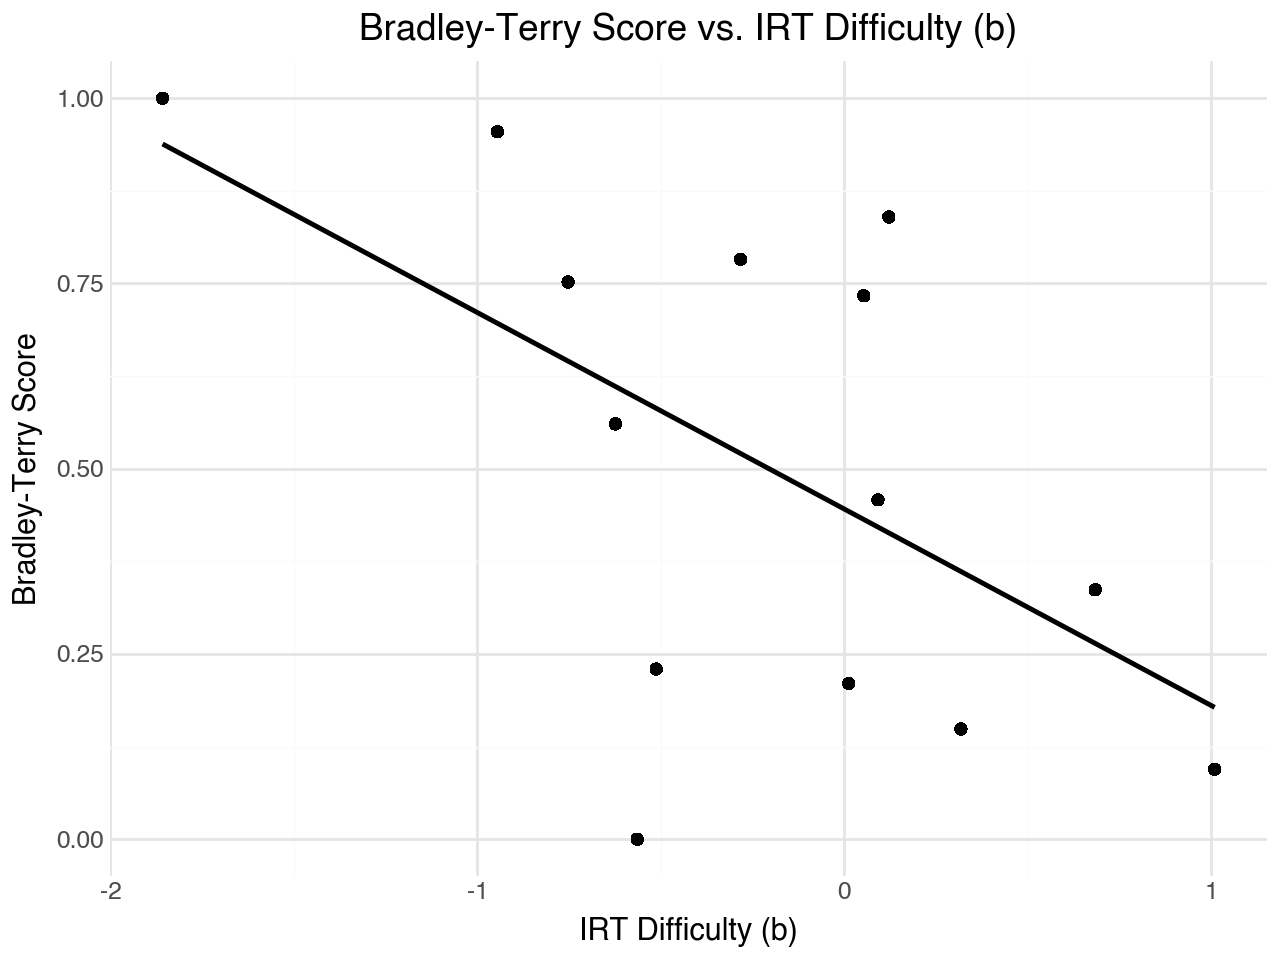

In [20]:
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_minimal

(
    ggplot(df_all, aes(x='difficulty_b', y='Bradley_Terry_Score')) +
    geom_point() +
    geom_smooth(method='lm', se=False) +
    labs(title='Bradley-Terry Score vs. IRT Difficulty (b)',
         x='IRT Difficulty (b)',
         y='Bradley-Terry Score') +
    theme_minimal()
)

In [21]:
import plotly.graph_objects as go
import textwrap
from scipy import stats

# Prepare hover text with wrapping
df_plot = df_all.copy()
df_plot['hover_text'] = df_plot['combined_text'].apply(
    lambda x: '<br>'.join(textwrap.wrap(str(x), width=70))
)

# Calculate linear regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_plot['difficulty_b'].dropna(), 
    df_plot['Bradley_Terry_Score'].dropna()
)
x_line = sorted(df_plot['difficulty_b'].dropna())
y_line = [slope * x + intercept for x in x_line]

# Create figure
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=df_plot['difficulty_b'],
    y=df_plot['Bradley_Terry_Score'],
    mode='markers',
    marker=dict(size=8, color='rgba(31, 119, 180, 0.6)'),
    hovertext=df_plot['hover_text'],
    hoverinfo='text+x+y',
    name='Items'
))

# Add regression line
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='rgba(255, 127, 14, 0.8)', width=2),
    name='Linear Fit',
    hoverinfo='skip'
))

# Update layout
fig.update_layout(
    title='Bradley-Terry Score vs. IRT Difficulty (b)',
    xaxis_title='IRT Difficulty (b)',
    yaxis_title='Bradley-Terry Score',
    hovermode='closest',
    template='plotly_white',
    width=900,
    height=600
)

fig.show()

In [150]:
# Sort by BT score and b separately to see the pattern
print("High BT, Low b (semantic severity ≠ empirical severity):")
print(p.scored_df.nlargest(3, 'Bradley_Terry_Score')[['item', 'Bradley_Terry_Score', 'difficulty_b']])

print("\nLow BT, High b:")
print(p.scored_df.nsmallest(3, 'Bradley_Terry_Score')[['item', 'Bradley_Terry_Score', 'difficulty_b']])

High BT, Low b (semantic severity ≠ empirical severity):
      item  Bradley_Terry_Score  difficulty_b
9   hadsx2             1.000000     -1.857874
7   hadsx8             0.954567     -0.945411
1  hadsx12             0.839685      0.121328

Low BT, High b:
       item  Bradley_Terry_Score  difficulty_b
11   hadsx9             0.000000     -0.564387
5   hadsx14             0.094386      1.009368
10   hadsx4             0.148758      0.317892


Response from Claude Haiku: 

No, it's probably not inverted—you've likely discovered something real about the items. The negative correlation is actually revealing.

Think about what it means:

- High BT Score = LLM judges this as a symptom that appears at higher depression severity
- High b = People actually endorse this only when depression is severe (high severity threshold)
- Negative correlation = Items that sound semantically severe are endorsed at LOW severity levels, and vice versa

This suggests a genuine mismatch between semantic severity and endorsement patterns. For example:

- An item with severe wording (e.g., "My life is a burden") might actually be endorsed across all depression levels—it's a common expression even among mildly depressed people. This would have HIGH BT but LOW b.
- An item with milder wording might only be endorsed by severely depressed people. This would have LOW BT but HIGH b.

## GRM

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import pytensor.tensor as pt
import arviz as az

# dat = df_merged.to_pandas() if isinstance(df_merged, pl.DataFrame) else df_merged.copy()
dat = pd.read_csv("../data/processed/facit_yount_2021_hadsx_itemtext_annotated.csv",
                  encoding="mac_iceland")
respondent_col = "id"   # change if needed

# Keep ordinal response (1..4), recode to 0..3
irt_df = dat[[respondent_col, "item", "resp"]].dropna().copy()
irt_df["y"] = irt_df["resp"].astype(int) - 1

# Safety checks
vals = sorted(irt_df["y"].unique())
if vals != [0, 1, 2, 3]:
    raise ValueError(f"Expected recoded categories [0,1,2,3], found {vals}")

person_codes, person_labels = pd.factorize(irt_df[respondent_col], sort=True)
item_codes, item_labels = pd.factorize(irt_df["item"], sort=True)

y = irt_df["y"].values
K = 4
J = len(item_labels)

coords = {
    "person": person_labels.astype(str),
    "item": item_labels.astype(str),
    "cut": np.arange(K - 1),
    "obs": np.arange(len(irt_df)),
}

# GRM:
# P(Y >= k) = sigmoid( a_i * (theta_n - b_ik) ), k=1,2,3
with pm.Model(coords=coords) as grm:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, dims="person")
    log_a = pm.Normal("log_a", mu=0.0, sigma=0.5, dims="item")
    a = pm.Deterministic("a", pt.exp(log_a), dims="item")

    # 3 ordered thresholds per item
    b_unordered = pm.Normal("b_unordered", mu=0.0, sigma=1.5, dims=("item", "cut"))
    b = pm.Deterministic("b", pt.sort(b_unordered, axis=1), dims=("item", "cut"))

    eta = a[item_codes, None] * (theta[person_codes, None] - b[item_codes, :])
    p_geq = pm.math.sigmoid(eta)  # shape: (n_obs, 3)

    # Category probabilities for 0..3
    p0 = 1 - p_geq[:, 0:1]
    p1 = p_geq[:, 0:1] - p_geq[:, 1:2]
    p2 = p_geq[:, 1:2] - p_geq[:, 2:3]
    p3 = p_geq[:, 2:3]
    p_cat = pt.concatenate([p0, p1, p2, p3], axis=1)
    p_cat = pt.clip(p_cat, 1e-9, 1.0)
    p_cat = p_cat / p_cat.sum(axis=1, keepdims=True)

    pm.Categorical("y_obs", p=p_cat, observed=y, dims="obs")

    idata_grm = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

print(az.summary(idata_grm, var_names=["a", "b"], hdi_prob=0.95))

In [ ]:
grm = pd.DataFrame(az.summary(idata_grm, var_names=["a", "b"], hdi_prob=0.95))

# Make the index a column
grm = grm.reset_index()

grm

,index,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,a[hadsx1],3.531,0.300,2.949,4.118,0.005,0.003,3029.0,3964.0,1.0
1,a[hadsx10],0.263,0.025,0.218,0.315,0.000,0.000,5305.0,4361.0,1.0
2,a[hadsx11],2.827,0.243,2.353,3.297,0.004,0.003,3006.0,3574.0,1.0
3,a[hadsx12],3.049,0.265,2.563,3.594,0.005,0.003,2958.0,4470.0,1.0
4,a[hadsx13],0.316,0.027,0.264,0.369,0.000,0.000,4871.0,4366.0,1.0
5,a[hadsx14],0.430,0.038,0.359,0.508,0.001,0.000,5464.0,4438.0,1.0
6,a[hadsx2],1.739,0.155,1.451,2.059,0.003,0.002,3680.0,3649.0,1.0
7,a[hadsx3],0.256,0.025,0.210,0.306,0.000,0.000,5389.0,3878.0,1.0
8,a[hadsx4],0.353,0.030,0.293,0.409,0.000,0.000,5671.0,4695.0,1.0
9,a[hadsx5],3.112,0.266,2.603,3.652,0.005,0.003,3108.0,3944.0,1.0


## Person-v-item

In [23]:
annotations = pd.read_csv("../data/processed/facit_yount_2021_hadsx_itemtext_annotated.csv",
                          encoding="mac_iceland")
annotations.head()

,table,section_id,item,instrument,instructions,section_prompt,item_text,option_text,resp,depression_indicator_mix,depression_indicator_most,depression_indicator_half,combined_text
0,facit_yount_2021_hadsx,main,hadsx14,Depression scale,NaN,During the past 7 days,I can enjoy a good book or radio or TV programme:,Sometimes,2,0,1,0,During the past 7 days: I can enjoy a good boo...
1,facit_yount_2021_hadsx,main,hadsx14,Depression scale,NaN,During the past 7 days,I can enjoy a good book or radio or TV programme:,Very seldom,4,1,1,1,During the past 7 days: I can enjoy a good boo...
2,facit_yount_2021_hadsx,main,hadsx14,Depression scale,NaN,During the past 7 days,I can enjoy a good book or radio or TV programme:,Not often,3,1,1,1,During the past 7 days: I can enjoy a good boo...
3,facit_yount_2021_hadsx,main,hadsx14,Depression scale,NaN,During the past 7 days,I can enjoy a good book or radio or TV programme:,Often,1,0,0,0,During the past 7 days: I can enjoy a good boo...
4,facit_yount_2021_hadsx,main,hadsx7,Depression scale,NaN,During the past 7 days,I can laugh and see the funny side of things:,Not at all,4,1,1,1,During the past 7 days: I can laugh and see th...


In [32]:
df_all_ind = df_all.merge(
    annotations[['item', 'resp', 'depression_indicator_most', 'depression_indicator_half', 'depression_indicator_mix']], 
    on=['item', 'resp'], 
    how='left')

# Add column to combine item and resp into 1 id
df_all_ind['item_resp_id'] = df_all_ind['item'].astype(str) + '_' + df_all_ind['resp'].astype(str)

df_all_ind.to_csv("../results/facit_yount_2021_hadsx_IRT_BT_indicators.csv", index=False)
print(df_all_ind.shape)
df_all_ind.head()

(8512, 15)


,id,date,item,resp,section_prompt,item_text,combined_text,discrimination_a,difficulty_b,theta,Bradley_Terry_Score,depression_indicator_most,depression_indicator_half,depression_indicator_mix,item_resp_id
0,2484565,1172250820,hadsx4,1,During the past 7 days,I get a sort of frightened feeling like ‘butte...,During the past 7 days: I get a sort of fright...,1.476496,0.317892,-0.037694,0.148758,0,0,0,hadsx4_1
1,2484565,1172250820,hadsx7,1,During the past 7 days,I can laugh and see the funny side of things:,During the past 7 days: I can laugh and see th...,3.034053,0.683944,-0.037694,0.336594,0,0,0,hadsx7_1
2,2484565,1172250820,hadsx14,1,During the past 7 days,I can enjoy a good book or radio or TV programme:,During the past 7 days: I can enjoy a good boo...,1.716032,1.009368,-0.037694,0.094386,0,0,0,hadsx14_1
3,2484576,1172250903,hadsx13,1,During the past 7 days,I can sit at ease and feel relaxed:,During the past 7 days: I can sit at ease and ...,1.791723,-0.512484,-0.596680,0.229603,0,0,0,hadsx13_1
4,2484576,1172250903,hadsx10,1,During the past 7 days,I look forward with enjoyment to things:,During the past 7 days: I look forward with en...,2.401031,0.012319,-0.596680,0.210098,0,0,0,hadsx10_1


not quite right

need to use the indicators to score whether the resp IS/IS NOT endorsing, not at the individual response level

In [33]:
p_v_i = df_all_ind[['id', 'item', 'depression_indicator_most', 'depression_indicator_half', 'depression_indicator_mix']].copy()

p_v_i.head()

,id,item,depression_indicator_most,depression_indicator_half,depression_indicator_mix
0,2484565,hadsx4,0,0,0
1,2484565,hadsx7,0,0,0
2,2484565,hadsx14,0,0,0
3,2484576,hadsx13,0,0,0
4,2484576,hadsx10,0,0,0


In [34]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def fit_bradley_terry_bipartite(df, id_col='id', item_col='item', outcome_col='depression_indicator_most'):
    """
    Fit Bradley-Terry model on bipartite graph: respondents vs. items.
    outcome=1 means respondent wins (or item wins - you can adjust interpretation below)
    """
    respondents = df[id_col].unique()
    items = df[item_col].unique()
    
    resp_to_idx = {r: i for i, r in enumerate(respondents)}
    item_to_idx = {it: j for j, it in enumerate(items)}
    
    n_resp = len(respondents)
    n_items = len(items)
    n_total = n_resp + n_items
    
    # Build win matrix: [resp_wins_vs_item[i,j], item_wins_vs_resp[j,i]]
    # resp_wins[i, j] = number of times respondent i beat item j
    resp_wins = np.zeros((n_resp, n_items))
    item_wins = np.zeros((n_items, n_resp))
    
    for _, row in df.iterrows():
        r_idx = resp_to_idx[row[id_col]]
        it_idx = item_to_idx[row[item_col]]
        
        if row[outcome_col] == 1:
            # Respondent wins (endorsed the symptom item)
            resp_wins[r_idx, it_idx] += 1
        else:
            # Item wins (respondent didn't endorse)
            item_wins[it_idx, r_idx] += 1
    
    # Fit Bradley-Terry using maximum likelihood
    # P(respondent i beats item j) = p_i / (p_i + p_j)
    def negative_log_likelihood(log_p):
        p = np.exp(log_p)
        ll = 0
        
        for i in range(n_resp):
            for j in range(n_items):
                n_ij = resp_wins[i, j]
                n_ji = item_wins[j, i]
                total_ij = n_ij + n_ji
                
                if total_ij > 0:
                    p_ij = p[i] / (p[i] + p[n_resp + j])
                    ll += n_ij * np.log(p_ij + 1e-10) + n_ji * np.log(1 - p_ij + 1e-10)
        
        return -ll
    
    # Fit model
    x0 = np.zeros(n_total)
    result = minimize(negative_log_likelihood, x0, method='BFGS')
    
    p_vals = np.exp(result.x)
    p_vals = p_vals / p_vals.sum()  # normalize
    
    # Extract respondent and item scores
    resp_scores = pd.DataFrame({
        'id': respondents,
        'BT_Score_Respondent': p_vals[:n_resp]
    }).sort_values('BT_Score_Respondent', ascending=False)
    
    item_scores = pd.DataFrame({
        'item': items,
        'BT_Score_Item': p_vals[n_resp:]
    }).sort_values('BT_Score_Item', ascending=False)
    
    return resp_scores, item_scores

# Run it
resp_scores, item_scores = fit_bradley_terry_bipartite(p_v_i, id_col='id', item_col='item', outcome_col='depression_indicator_most')

print("Respondent Bradley-Terry Scores:")
print(resp_scores.head(10))
print("\nItem Bradley-Terry Scores:")
print(item_scores.head(10))

# Save
resp_scores.to_csv("../results/respondent_bradley_terry_scores.csv", index=False)
item_scores.to_csv("../results/item_bradley_terry_scores.csv", index=False)

Respondent Bradley-Terry Scores:
          id  BT_Score_Respondent
430  2514417             0.020910
358  2498930             0.020899
363  2499260             0.020899
216  2494518             0.020898
197  2494117             0.020898
503  2545879             0.020882
600  2498414             0.020880
605  2612587             0.020878
607  2614784             0.020878
606  2612770             0.020878

Item Bradley-Terry Scores:
       item  BT_Score_Item
2   hadsx14   2.818737e-08
1    hadsx7   1.908715e-08
0    hadsx4   6.315315e-09
13  hadsx12   4.511539e-09
12  hadsx11   4.458570e-09
9    hadsx5   3.964012e-09
4   hadsx10   3.652744e-09
8    hadsx6   2.168305e-09
3   hadsx13   1.290917e-09
6    hadsx9   1.101904e-09


In [38]:
df_all_ind_rescored = df_all_ind.merge(
    item_scores.rename(columns={'BT_Score_Item': 'BT_Score_Item_Bipartite'}),
    on='item',
    how='left'
).merge(
    resp_scores.rename(columns={'BT_Score_Respondent': 'BT_Score_Respondent_Bipartite'}),
    on='id',
    how='left'
)

df_all_ind_rescored.to_csv("../results/facit_yount_2021_hadsx_IRT_BT_full.csv", index=False)
print(df_all_ind_rescored.shape)
df_all_ind_rescored.head()

(8512, 17)


,id,date,item,resp,section_prompt,item_text,combined_text,discrimination_a,difficulty_b,theta,Bradley_Terry_Score,depression_indicator_most,depression_indicator_half,depression_indicator_mix,item_resp_id,BT_Score_Item_Bipartite,BT_Score_Respondent_Bipartite
0,2484565,1172250820,hadsx4,1,During the past 7 days,I get a sort of frightened feeling like ‘butte...,During the past 7 days: I get a sort of fright...,1.476496,0.317892,-0.037694,0.148758,0,0,0,hadsx4_1,6.315315e-09,3.624124e-09
1,2484565,1172250820,hadsx7,1,During the past 7 days,I can laugh and see the funny side of things:,During the past 7 days: I can laugh and see th...,3.034053,0.683944,-0.037694,0.336594,0,0,0,hadsx7_1,1.908715e-08,3.624124e-09
2,2484565,1172250820,hadsx14,1,During the past 7 days,I can enjoy a good book or radio or TV programme:,During the past 7 days: I can enjoy a good boo...,1.716032,1.009368,-0.037694,0.094386,0,0,0,hadsx14_1,2.818737e-08,3.624124e-09
3,2484576,1172250903,hadsx13,1,During the past 7 days,I can sit at ease and feel relaxed:,During the past 7 days: I can sit at ease and ...,1.791723,-0.512484,-0.596680,0.229603,0,0,0,hadsx13_1,1.290917e-09,1.146075e-09
4,2484576,1172250903,hadsx10,1,During the past 7 days,I look forward with enjoyment to things:,During the past 7 days: I look forward with en...,2.401031,0.012319,-0.596680,0.210098,0,0,0,hadsx10_1,3.652744e-09,1.146075e-09


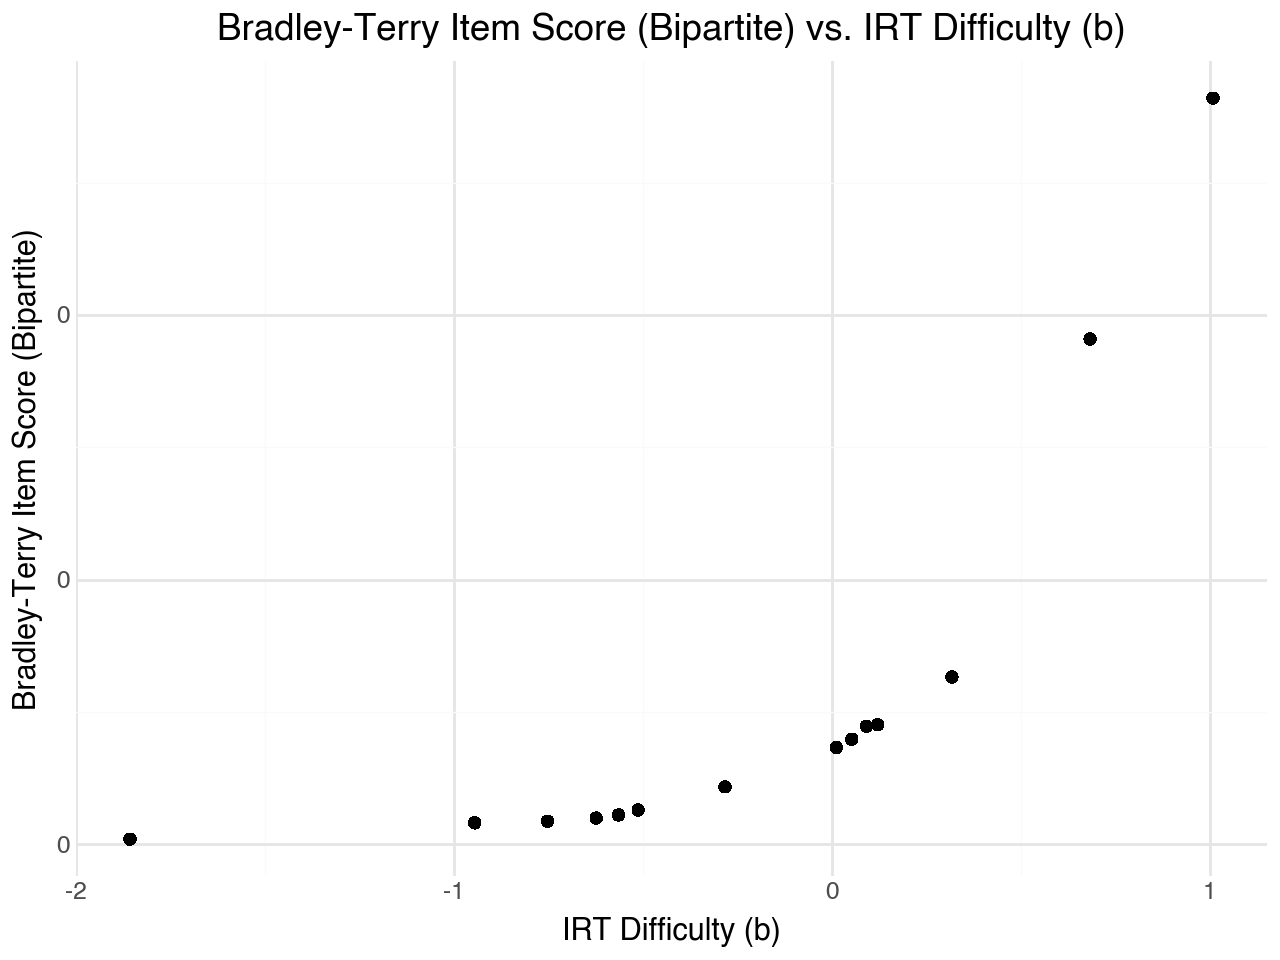

In [43]:
# Plot the difficulty_b vs. BT_Score_Item_Bipartite using plotnine
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_minimal

(
    ggplot(df_all_ind_rescored, aes(x='difficulty_b', y='BT_Score_Item_Bipartite')) +
    geom_point() +
    # geom_smooth(method='lowess', se=False) +
    labs(title='Bradley-Terry Item Score (Bipartite) vs. IRT Difficulty (b)',
         x='IRT Difficulty (b)',
         y='Bradley-Terry Item Score (Bipartite)') +
    theme_minimal()
)